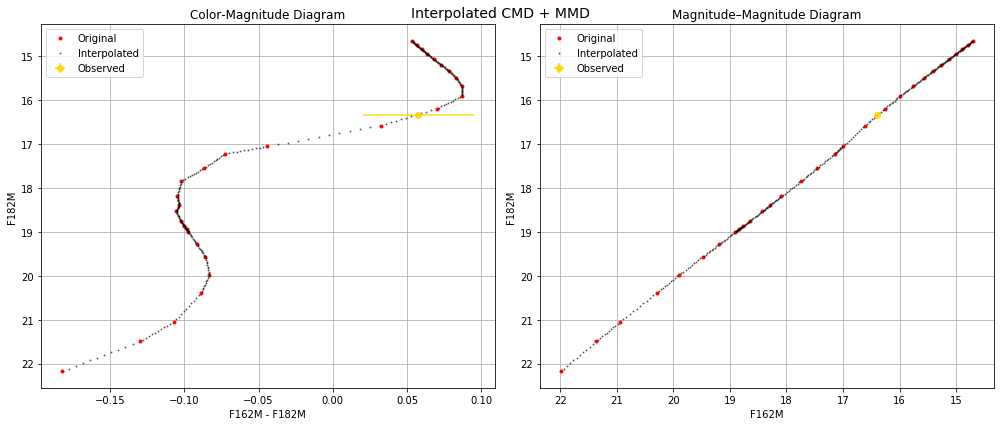

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
from matplotlib.colors import LogNorm
import csv
from scipy.stats import chi2

# === Setup ===
iso_dir = 'isochrones/'
# output_dir = 'output_diagrams/'
# os.makedirs(output_dir, exist_ok=True)

# --- Static Parameters ---
star_index = 6
dist = 4500
metallicity = 0
log_age_arr = np.log10([1e6])  # 1 Myr

# Models
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)

# Filters
filt_list = ['jwst,F162M', 'jwst,F182M', 'jwst,F200W']
filters = ['m_jwst_F162M', 'm_jwst_F182M', 'm_jwst_F200W']

filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# --- Load star data ---
def load_star_data(csv_path, index=0):
    sample_mags, sample_errs = [], []
    with open(csv_path, mode='r') as file:
        reader = csv.reader(file)
        next(reader)
        for line in reader:
            mags = [float(line[i]) for i in range(1, len(line), 2)]
            errs = [float(line[i]) for i in range(2, len(line), 2)]
            sample_mags.append(mags)
            sample_errs.append(errs)
    return sample_mags[index][:3], sample_errs[index][:3]  # Include F200W

# --- Interpolate Isochrone Points ---
def interpolate_isochrone(isochrone, num_interp=10):
    masses = isochrone.points['mass']
    m1 = isochrone.points['m_jwst_F162M']
    m2 = isochrone.points['m_jwst_F182M']
    m3 = isochrone.points['m_jwst_F200W']

    # Collect original + interpolated points
    interp_data = []

    for i in range(len(masses) - 1):
        mass1, mass2 = masses[i], masses[i+1]
        m1_1, m1_2 = m1[i], m1[i+1]
        m2_1, m2_2 = m2[i], m2[i+1]
        m3_1, m3_2 = m3[i], m3[i+1]

        # Interpolate mass values
        interp_masses = np.linspace(mass1, mass2, num=num_interp+2)[1:-1]
        interp_m1 = np.linspace(m1_1, m1_2, num=num_interp+2)[1:-1]
        interp_m2 = np.linspace(m2_1, m2_2, num=num_interp+2)[1:-1]
        interp_m3 = np.linspace(m3_1, m3_2, num=num_interp+2)[1:-1]

        for m, im1, im2, im3 in zip(interp_masses, interp_m1, interp_m2, interp_m3):
            interp_data.append((m, im1, im2, im3, False))  # False = interpolated

    # Add original points
    for i in range(len(masses)):
        interp_data.append((masses[i], m1[i], m2[i], m3[i], True))  # True = original

    # Convert to structured array
    interp_data = sorted(interp_data, key=lambda x: x[0])
    dtype = [('mass', float), ('m_jwst_F162M', float), ('m_jwst_F182M', float), ('m_jwst_F200W', float), ('is_original', bool)]
    interp_array = np.array(interp_data, dtype=dtype)
    return interp_array

# --- Apply Dereddening ---
def apply_dereddening(mags, AKs, wavelengths):
    return [
        m - red_law.Cardelli89(wavelengths[filters[i]], AKs)
        for i, m in enumerate(mags)
    ]

# --- Compute Errors ---
def calculate_errors(errs):
    color_err = np.sqrt(errs[0]**2 + errs[1]**2)
    mag_err = errs[1]
    return color_err, mag_err

# --- Plotting Function ---
def plot_cmd_and_mmd(interp_table, dered_mags, errors, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_cmd, ax_mmd = axes
    m162_d, m182_d, _ = dered_mags
    color_err, mag_err = errors

    # Split by origin
    original = interp_table[interp_table['is_original']]
    interp = interp_table[~interp_table['is_original']]

    # === Color-Magnitude Diagram (CMD) ===
    colors_orig = original['m_jwst_F162M'] - original['m_jwst_F182M']
    mags_orig = original['m_jwst_F182M']
    colors_interp = interp['m_jwst_F162M'] - interp['m_jwst_F182M']
    mags_interp = interp['m_jwst_F182M']

    ax_cmd.plot(colors_orig, mags_orig, 'ro', markersize=3, label='Original')
    ax_cmd.plot(colors_interp, mags_interp, 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_cmd.errorbar(m162_d - m182_d, m182_d, xerr=color_err, yerr=mag_err,
                    fmt='o', color='gold', alpha=0.9, label='Observed')

    ax_cmd.set_xlabel("F162M - F182M")
    ax_cmd.set_ylabel("F182M")
    ax_cmd.invert_yaxis()
    ax_cmd.set_title("Color-Magnitude Diagram")
    ax_cmd.grid(True)
    ax_cmd.legend()

    # === Magnitude-Magnitude Diagram (MMD) ===
    ax_mmd.plot(original['m_jwst_F162M'], original['m_jwst_F182M'], 'ro', markersize=3, label='Original')
    ax_mmd.plot(interp['m_jwst_F162M'], interp['m_jwst_F182M'], 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_mmd.errorbar(m162_d, m182_d, xerr=errs[0], yerr=errs[1],
                    fmt='o', color='gold', alpha=0.9, label='Observed')

    ax_mmd.set_xlabel("F162M")
    ax_mmd.set_ylabel("F182M")
    ax_mmd.invert_yaxis()
    ax_mmd.invert_xaxis()
    ax_mmd.set_title("Magnitude–Magnitude Diagram")
    ax_mmd.grid(True)
    ax_mmd.legend()

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# === Main Execution ===
csv_path = '/scratch/wyz5rge/synthetic-hr/notebooks/2025/01-28_chi-square-reverse-modeling/s284.csv'
mags, errs = load_star_data(csv_path, star_index)
AKs_val = 0.81

# Deredden
dered_mags = apply_dereddening(mags, AKs_val, filter_wavelengths)
errors = calculate_errors(errs)

# Generate isochrone and interpolate
iso = synthetic.IsochronePhot(log_age_arr[0], AKs=0.0, distance=dist,
                               metallicity=metallicity,
                               evo_model=evo_model, atm_func=atm_func,
                               red_law=red_law, filters=filt_list,
                               iso_dir=iso_dir)

interp_table = interpolate_isochrone(iso, num_interp=10)

# Plot CMD
plot_cmd_and_mmd(interp_table, dered_mags, errors, "Interpolated CMD + MMD")

Chi-squared rejection threshold (reduced, 95% confidence): 2.996
Top 10 best fits (lowest reduced chi-squared):
Mass = 0.3636 Msun, Chi-squared = 0.4378
Mass = 0.3545 Msun, Chi-squared = 0.4713
Mass = 0.3727 Msun, Chi-squared = 3.7301
Mass = 0.3455 Msun, Chi-squared = 3.8307
Mass = 0.3818 Msun, Chi-squared = 10.3482
Mass = 0.3364 Msun, Chi-squared = 10.5158
Mass = 0.3909 Msun, Chi-squared = 20.2921
Mass = 0.3273 Msun, Chi-squared = 20.5268
Mass = 0.4000 Msun, Chi-squared = 33.5618
Mass = 0.3182 Msun, Chi-squared = 33.8636


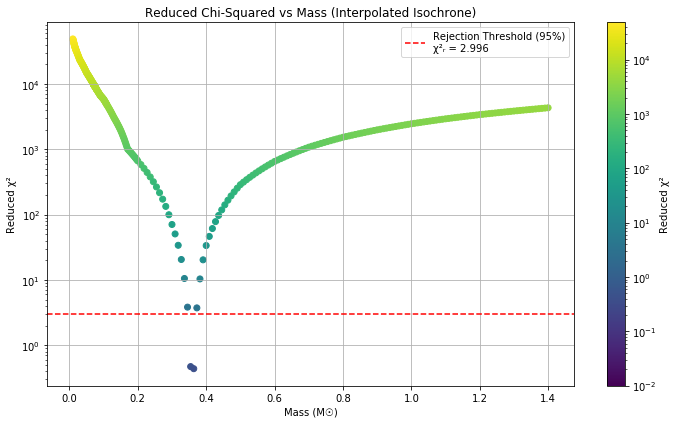

In [7]:
# === Generate Reddened Isochrone and Interpolate ===
iso_reddened = synthetic.IsochronePhot(log_age_arr[0], AKs=AKs_val, distance=dist,
                                       metallicity=metallicity,
                                       evo_model=evo_model, atm_func=atm_func,
                                       red_law=red_law, filters=filt_list,
                                       iso_dir=iso_dir)

interp_reddened = interpolate_isochrone(iso_reddened, num_interp=10)

# === Load observed star (again, just for clarity) ===
obs_mags, obs_errs = load_star_data(csv_path, star_index)

# === Chi-square calculation with interpolated isochrone ===
def chi_square_interp_isochrone(interp_table, obs_mags, obs_errors):
    DOF = len(obs_mags) - 1  # Degrees of freedom
    chi_sq_vals = []
    mass_vals = []

    for entry in interp_table:
        model_mags = [entry[f] for f in filters]
        chi_sq = sum(
            ((obs_mags[i] - model_mags[i]) ** 2) / max(obs_errors[i]**2, 1e-3)
            for i in range(len(obs_mags))
        ) / DOF
        chi_sq_vals.append(chi_sq)
        mass_vals.append(entry['mass'])

    return np.array(mass_vals), np.array(chi_sq_vals)

# === Compute chi-squared values ===
masses, chi_squares = chi_square_interp_isochrone(interp_reddened, obs_mags, obs_errs)

# === Compute Chi-Squared Rejection Threshold ===
alpha = 0.05  # 95% confidence level
DOF = len(obs_mags) - 1
chi2_critical = chi2.ppf(1 - alpha, df=DOF)
reduced_chi2_threshold = chi2_critical / DOF

print(f"Chi-squared rejection threshold (reduced, 95% confidence): {reduced_chi2_threshold:.3f}")

# === Sort and report top 10 matches ===
top_indices = np.argsort(chi_squares)[:10]
print("Top 10 best fits (lowest reduced chi-squared):")
for i in top_indices:
    print(f"Mass = {masses[i]:.4f} Msun, Chi-squared = {chi_squares[i]:.4f}")

# === Plot: Mass vs Chi-Squared with Rejection Line ===
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(masses, chi_squares, c=chi_squares, cmap='viridis', norm=LogNorm(vmin=1e-2, vmax=max(chi_squares)))
ax.axhline(reduced_chi2_threshold, color='red', linestyle='--', linewidth=1.5, label=f"Rejection Threshold (95%)\nχ²ᵣ = {reduced_chi2_threshold:.3f}")
ax.set_xlabel("Mass (M☉)")
ax.set_ylabel("Reduced χ²")
ax.set_title("Reduced Chi-Squared vs Mass (Interpolated Isochrone)")
ax.set_yscale("log")
ax.grid(True)
ax.legend()
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Reduced χ²")
plt.tight_layout()
plt.show()